### 동일한 주식매매 환경을 기준으로 Q-Learning, DQN, A3C, A2C, TRPO, PPO를 비교

In [ ]:
# 다음 실제 수익률	정답에 가까운 행동
# >= +1%	BUY
# -1% < 수익률 < +1%	HOLD
# <= -1%	SELL

In [ ]:
# 현재 환경에서 HOLD를 주식을 계속 보유한다는 의미가 아니라 포지션을 0으로 청산하고 관망한다는 의미로 정의

## 1. 공통 주식매매 환경

In [13]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

BUY = 0
HOLD = 1
SELL = 2

ACTION_NAMES = {
    BUY: "BUY",
    HOLD: "HOLD",
    SELL: "SELL"
}


def make_features(df):
    df = df.copy()

    # 수익률
    df["ret1"] = df["Close"].pct_change()
    df["ret5"] = df["Close"].pct_change(5)
    df["ret20"] = df["Close"].pct_change(20)

    # 이동평균
    df["ma5"] = df["Close"].rolling(5).mean()
    df["ma20"] = df["Close"].rolling(20).mean()

    # 이동평균 대비 현재가격
    df["ma5_ratio"] = df["Close"] / df["ma5"] - 1
    df["ma20_ratio"] = df["Close"] / df["ma20"] - 1

    # 변동성
    df["volatility"] = df["ret1"].rolling(20).std()

    # 거래량 변화
    df["volume_change"] = df["Volume"].pct_change()

    # 다음 날 수익률
    df["next_return"] = (
        df["Close"].shift(-1) / df["Close"] - 1
    )

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df = df.dropna().reset_index(drop=True)

    return df


class StockTradingEnv(gym.Env):

    def __init__(
        self,
        df,
        transaction_cost=0.001,
        threshold=0.02,
        rule_bonus=0.002
    ):
        super().__init__()

        self.df = make_features(df)

        self.feature_cols = [
            "ret1",
            "ret5",
            "ret20",
            "ma5_ratio",
            "ma20_ratio",
            "volatility",
            "volume_change"
        ]

        self.transaction_cost = transaction_cost

        # ±2%
        self.threshold = threshold

        self.rule_bonus = rule_bonus

        # 0 BUY
        # 1 HOLD
        # 2 SELL
        self.action_space = spaces.Discrete(3)

        n_features = len(self.feature_cols) + 1

        self.observation_space = spaces.Box(
            low=-10,
            high=10,
            shape=(n_features,),
            dtype=np.float32
        )

        self.current_step = 0
        self.position = 0
        self.portfolio_value = 1.0

    def _get_state(self):

        row = self.df.iloc[self.current_step]

        features = row[
            self.feature_cols
        ].values.astype(np.float32)

        state = np.concatenate([
            features,
            np.array(
                [self.position],
                dtype=np.float32
            )
        ])

        return np.nan_to_num(
            state,
            nan=0.0,
            posinf=10.0,
            neginf=-10.0
        )

    def _target_action(self, next_return):

        # +1% 이상 → 매수
        if next_return >= 0.01:
            return BUY

        # -1% 이하 → 매도
        elif next_return <= -0.01:
            return SELL

        # -1% ~ +1% → 관망
        else:
            return HOLD

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0
        self.portfolio_value = 1.0

        return self._get_state(), {}

    def step(self, action):

        row = self.df.iloc[
            self.current_step
        ]

        next_return = float(
            row["next_return"]
        )

        old_position = self.position

        if action == BUY:
            new_position = 1

        elif action == SELL:
            new_position = -1

        else:
            new_position = 0

        # 거래 비용
        trade_size = abs(
            new_position - old_position
        )

        cost = (
            self.transaction_cost *
            trade_size
        )

        # 투자 수익률
        strategy_return = (
            new_position *
            next_return -
            cost
        )

        # ±1% 규칙
        target_action = self._target_action(
            next_return
        )

        if action == target_action:
            rule_reward = self.rule_bonus
        else:
            rule_reward = -self.rule_bonus

        reward = (
            strategy_return +
            rule_reward
        )

        self.position = new_position

        self.portfolio_value *= (
            1 + strategy_return
        )

        self.current_step += 1

        terminated = (
            self.current_step >=
            len(self.df) - 1
        )

        truncated = False

        if terminated:
            next_state = np.zeros(
                self.observation_space.shape,
                dtype=np.float32
            )
        else:
            next_state = self._get_state()

        info = {
            "portfolio_value":
                self.portfolio_value,

            "next_return":
                next_return,

            "target_action":
                target_action,

            "action":
                action,

            "strategy_return":
                strategy_return
        }

        return (
            next_state,
            float(reward),
            terminated,
            truncated,
            info
        )

## 2. Q-Learning

- Q-Learning은 신경망을 사용하지 않으므로 연속형 주가 특징을 구간화(discretization) 해야 합니다.

In [14]:
import numpy as np
import pandas as pd
import yfinance as yf

# =========================================
# 1. 삼성전자 데이터 다운로드
# =========================================

df = yf.download(
    "005930.KS",
    start="2018-01-01",
    end="2026-08-19",
    auto_adjust=False,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()

df = df[
    ["Date", "Open", "High", "Low", "Close", "Volume"]
].copy()


# =========================================
# 2. Train / Test 분리
# =========================================

split = int(len(df) * 0.8)

train_df = df.iloc[:split].copy()
test_df = df.iloc[split:].copy()

print("전체:", len(df))
print("학습:", len(train_df))
print("테스트:", len(test_df))


# =========================================
# 3. 강화학습 환경 생성
# =========================================

env = StockTradingEnv(train_df)

state, _ = env.reset()

print("State:", state)
print("State size:", len(state))

전체: 2113
학습: 1690
테스트: 423
State: [-0.02772355  0.01301871 -0.02391219 -0.00954654 -0.00270351  0.01785506
  0.03765162  0.        ]
State size: 8


In [ ]:
# 일봉 데이터라면 대략 2,113 거래일입니다.
# 학습: 1690, 테스트: 423은 데이터를 시간 순서대로 약 80%/20%로 나눈 결과입니다.

In [15]:
# 현재 State는 총 8개의 값으로 구성되어 있습니다.

# 번호	값	의미	해석
# 1	-0.02772	1일 수익률	약 -2.77%
# 2	0.01308	5일 수익률	약 +1.30%
# 3	-0.02391	20일 수익률	약 -2.39%
# 4	-0.00954	MA5 괴리율	5일 평균보다 약 -0.95% 낮음
# 5	-0.00270	MA20 괴리율	20일 평균보다 약 -0.27% 낮음
# 6	0.01785	20일 변동성	약 1.79%
# 7	0.03765	거래량 변화율	약 +3.77%
# 8	0.0	현재 포지션	관망 상태

In [16]:
# 금 더 쉽게 보면 현재 시장 상황은 대략 이렇습니다.

# 최근 1일   : -2.77% ↓
# 최근 5일   : +1.30% ↑
# 최근 20일  : -2.39% ↓


# 5일 평균 대비  : -0.95%
# 20일 평균 대비 : -0.27%


# 변동성          : 1.79%
# 거래량 변화     : +3.77%


# 현재 포지션     : 관망

In [17]:
# 여기서 특히 주의할 점은 State의 첫 번째 값 -2.77% 때문에 바로 SELL한다는 뜻은 아니라는 것입니다. 
#     강화학습 에이전트는 8개 상태를 모두 보고 행동을 결정합니다.

- BUY/HOLD/SELL로 얼마나 분포되는지 확인

In [18]:
temp = make_features(df)

temp["target"] = np.where(
    temp["next_return"] >= 0.01,
    "BUY",
    np.where(
        temp["next_return"] <= -0.01,
        "SELL",
        "HOLD"
    )
)

print("=== 행동별 개수 ===")
print(temp["target"].value_counts())

print("\n=== 행동별 비율 ===")
print(
    temp["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== 행동별 개수 ===
target
HOLD    1011
BUY      543
SELL     522
Name: count, dtype: int64

=== 행동별 비율 ===
target
HOLD    48.70
BUY     26.16
SELL    25.14
Name: proportion, dtype: float64


- Q-Learning 학습

- 핵심은 상태 8개를 이산화해서 Q-table의 key로 바꾸는 것입니다.

In [19]:
import numpy as np
import pandas as pd

# =========================================
# 1. Q-Learning 설정
# =========================================

# 상태값을 몇 개 구간으로 나눌지
N_BINS = 7

# 학습률
alpha = 0.1

# 할인율
gamma = 0.95

# 탐험 확률
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

# 학습 반복 횟수
episodes = 300


# =========================================
# 2. 연속형 State -> 이산형 State
# =========================================

def discretize_state(state):
    """
    StockTradingEnv의 연속형 state를
    Q-Learning용 이산 상태로 변환
    """

    state = np.array(state, dtype=np.float32)

    # 마지막 값은 position(-1, 0, 1)
    features = state[:-1]
    position = int(state[-1])

    # 수익률/괴리율/변동성/거래량 변화값을
    # 너무 큰 범위로 가지 않도록 제한
    features = np.clip(
        features,
        -0.10,
        0.10
    )

    # -10% ~ +10%를 N_BINS 구간으로 분리
    bins = np.linspace(
        -0.10,
        0.10,
        N_BINS - 1
    )

    discrete_features = np.digitize(
        features,
        bins
    )

    # position까지 state에 포함
    discrete_state = tuple(
        discrete_features.tolist()
        + [position]
    )

    return discrete_state


# =========================================
# 3. Q-table
# =========================================

Q = {}


def get_q_values(state):
    """
    state에 해당하는
    BUY, HOLD, SELL Q값 반환
    """

    if state not in Q:
        Q[state] = np.zeros(
            3,
            dtype=np.float32
        )

    return Q[state]


# =========================================
# 4. 학습 환경
# =========================================

env = StockTradingEnv(
    train_df,
    threshold=0.02,
    transaction_cost=0.001,
    rule_bonus=0.002
)


# =========================================
# 5. Q-Learning 학습
# =========================================

history = []

for episode in range(episodes):

    state, _ = env.reset()

    state = discretize_state(state)

    done = False

    total_reward = 0.0
    trade_count = 0

    buy_count = 0
    hold_count = 0
    sell_count = 0

    while not done:

        # ---------------------------------
        # epsilon-greedy 행동 선택
        # ---------------------------------

        if np.random.random() < epsilon:

            # 탐험
            action = env.action_space.sample()

        else:

            # 현재 가장 높은 Q값 행동
            q_values = get_q_values(state)

            action = int(
                np.argmax(q_values)
            )

        # ---------------------------------
        # 환경에서 한 단계 진행
        # ---------------------------------

        next_state, reward, terminated, truncated, info = env.step(
            action
        )

        done = terminated or truncated

        next_state_discrete = discretize_state(
            next_state
        )

        # ---------------------------------
        # Q-Learning 업데이트
        # ---------------------------------

        current_q = get_q_values(state)[action]

        if done:

            target = reward

        else:

            max_next_q = np.max(
                get_q_values(
                    next_state_discrete
                )
            )

            target = (
                reward
                + gamma * max_next_q
            )

        # Q(s,a) 업데이트
        get_q_values(state)[action] += (
            alpha
            * (
                target
                - current_q
            )
        )

        # ---------------------------------
        # 통계
        # ---------------------------------

        if action == BUY:
            buy_count += 1

        elif action == HOLD:
            hold_count += 1

        elif action == SELL:
            sell_count += 1

        if action != HOLD:
            trade_count += 1

        total_reward += reward

        state = next_state_discrete


    # =====================================
    # epsilon 감소
    # =====================================

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


    history.append({
        "episode": episode + 1,
        "reward": total_reward,
        "portfolio_value": info["portfolio_value"],
        "buy": buy_count,
        "hold": hold_count,
        "sell": sell_count,
        "epsilon": epsilon
    })


    # =====================================
    # 중간 결과 출력
    # =====================================

    if (
        episode == 0
        or (episode + 1) % 20 == 0
    ):

        print(
            f"Episode {episode + 1:3d} | "
            f"Reward: {total_reward:8.4f} | "
            f"Portfolio: {info['portfolio_value']:8.4f} | "
            f"BUY: {buy_count:4d} | "
            f"HOLD: {hold_count:4d} | "
            f"SELL: {sell_count:4d} | "
            f"Epsilon: {epsilon:.3f}"
        )


print("\n학습 완료")
print("Q-table 상태 개수:", len(Q))

Episode   1 | Reward:  -2.1793 | Portfolio:   0.2817 | BUY:  532 | HOLD:  535 | SELL:  585 | Epsilon: 0.995
Episode  20 | Reward:  -1.1142 | Portfolio:   0.7735 | BUY:  552 | HOLD:  543 | SELL:  557 | Epsilon: 0.905
Episode  40 | Reward:  -0.6432 | Portfolio:   1.1188 | BUY:  563 | HOLD:  544 | SELL:  545 | Epsilon: 0.818
Episode  60 | Reward:   0.8659 | Portfolio:   3.7474 | BUY:  564 | HOLD:  555 | SELL:  533 | Epsilon: 0.740
Episode  80 | Reward:   0.9001 | Portfolio:   3.6300 | BUY:  531 | HOLD:  603 | SELL:  518 | Epsilon: 0.670
Episode 100 | Reward:   1.2266 | Portfolio:   5.5350 | BUY:  528 | HOLD:  582 | SELL:  542 | Epsilon: 0.606
Episode 120 | Reward:   1.9669 | Portfolio:  10.5186 | BUY:  543 | HOLD:  599 | SELL:  510 | Epsilon: 0.548
Episode 140 | Reward:   2.4809 | Portfolio:  13.4494 | BUY:  515 | HOLD:  670 | SELL:  467 | Epsilon: 0.496
Episode 160 | Reward:   4.2806 | Portfolio:  73.8237 | BUY:  523 | HOLD:  634 | SELL:  495 | Epsilon: 0.448
Episode 180 | Reward:   3.50

In [20]:
# 숫자는 실제 학습마다 달라집니다. 
# 초기에는 epsilon이 높아서 BUY/HOLD/SELL을 거의 무작위로 선택하지만 학습이 진행될수록 Q-table을 이용하는 비율이 높아집니다.
# 학습이 끝났다면 history를 DataFrame으로 확인할 수 있습니다.

In [21]:
history_df = pd.DataFrame(history)

print(history_df.tail(10))

     episode    reward  portfolio_value  buy  hold  sell   epsilon
290      291  7.582241      1300.878505  509   717   426  0.232550
291      292  6.622178       564.053855  474   681   497  0.231387
292      293  6.254588       416.063906  483   704   465  0.230230
293      294  6.839664       628.631113  490   732   430  0.229079
294      295  6.747732       609.520269  490   709   453  0.227934
295      296  6.572685       510.916168  517   728   407  0.226794
296      297  6.423100       430.144565  498   737   417  0.225660
297      298  7.423959      1131.078535  490   717   445  0.224532
298      299  6.391815       482.249451  525   707   420  0.223409
299      300  7.078940       894.461712  520   695   437  0.222292


- 학습이 제대로 되고 있는지 그래프로 확인하세요.

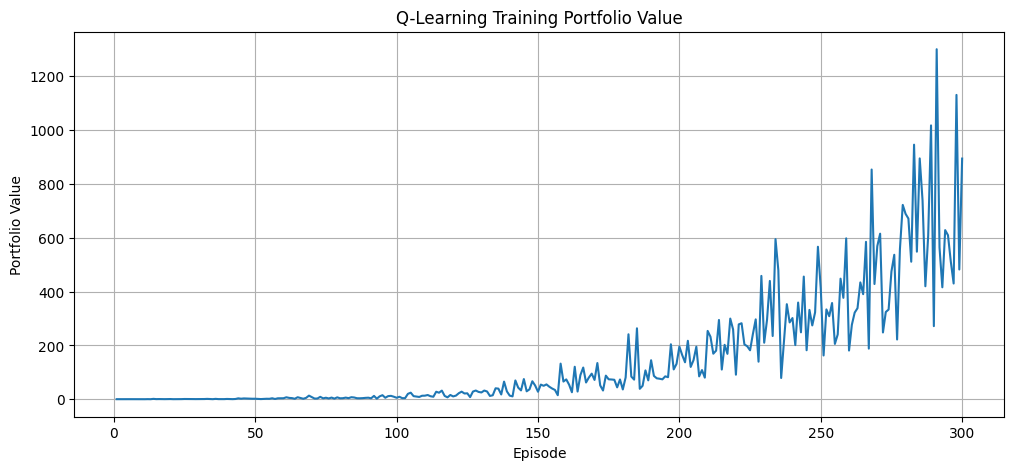

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    history_df["episode"],
    history_df["portfolio_value"]
)

plt.xlabel("Episode")
plt.ylabel("Portfolio Value")
plt.title("Q-Learning Training Portfolio Value")

plt.grid()

plt.show()

- 학습 데이터에서 수익률이 높게 나오는 것이 아니라, 사용하지 않은 test_df에서 성능을 확인

In [23]:
# =========================================
# Q-Learning Test
# =========================================

test_env = StockTradingEnv(
    test_df,
    threshold=0.02,
    transaction_cost=0.001,
    rule_bonus=0.002
)

state, _ = test_env.reset()

state = discretize_state(state)

done = False

test_results = []

while not done:

    # 테스트에서는 탐험하지 않음
    # epsilon = 0

    q_values = get_q_values(state)

    action = int(
        np.argmax(q_values)
    )

    next_state, reward, terminated, truncated, info = test_env.step(
        action
    )

    done = terminated or truncated

    test_results.append({
        "step": test_env.current_step,
        "action": ACTION_NAMES[action],
        "next_return": info["next_return"],
        "strategy_return": info["strategy_return"],
        "portfolio_value": info["portfolio_value"]
    })

    state = discretize_state(
        next_state
    )


test_result_df = pd.DataFrame(
    test_results
)

print(test_result_df.head(20))

    step action  next_return  strategy_return  portfolio_value
0      1    BUY     0.012915         0.011915         1.011915
1      2   HOLD    -0.032787        -0.001000         1.010903
2      3   HOLD    -0.001883        -0.000000         1.010903
3      4    BUY     0.009434         0.008434         1.019429
4      5    BUY     0.016822         0.016822         1.036578
5      6   SELL    -0.014706         0.012706         1.049749
6      7    BUY     0.001866        -0.000134         1.049608
7      8   SELL    -0.009311         0.007311         1.057282
8      9    BUY     0.003759         0.001759         1.059142
9     10   HOLD     0.018727        -0.001000         1.058083
10    11   HOLD     0.027574         0.000000         1.058083
11    12    BUY    -0.008945        -0.009945         1.047561
12    13    BUY     0.034296         0.034296         1.083488
13    14   HOLD    -0.020942        -0.001000         1.082404
14    15    BUY    -0.014260        -0.015260         1

In [ ]:
# 열	의미
# step	테스트 데이터의 거래일 순서
# action	Q-Learning이 선택한 행동
# next_return	그 행동 이후 실제 다음 날 주가 수익률
# strategy_return	행동에 따른 실제 전략 수익률(거래비용 포함)
# portfolio_value	초기자산 1.0 기준 누적 자산

In [ ]:
# 20개 구간만 놓고 보면 대략

# (1.059532−1)×100=5.9532%

# 즉 **약 +5.95%**입니다.

# 하지만 이것만 보고 Q-Learning 성능이 좋다고 판단하면 안 됩니다.

# 테스트 데이터가 423개이므로 423개 전체를 평가해야 합니다

- 최종 결과는:

In [29]:
print(
    "최종 Portfolio Value:",
    test_result_df["portfolio_value"].iloc[-1]
)

total_return = (
    test_result_df["portfolio_value"].iloc[-1]
    - 1
) * 100

print(
    f"Q-Learning 테스트 수익률: {total_return:.2f}%"
)

최종 Portfolio Value: 2.4605204319678977
Q-Learning 테스트 수익률: 146.05%


- 매수/관망/매도 비율  확인

In [30]:
print(
    test_result_df["action"].value_counts()
)

print()

print(
    test_result_df["action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

action
BUY     315
HOLD     55
SELL     31
Name: count, dtype: int64

action
BUY     78.55
HOLD    13.72
SELL     7.73
Name: proportion, dtype: float64


## 3. DQN

- DQN은 Q-table 대신 신경망으로

In [ ]:
# # Q(BUY)
# # Q(HOLD)
# # Q(SELL)
# 을 추정합니다.

In [32]:
# ============================================
# DQN - 삼성전자 주식매매
# ============================================

import random
from collections import deque

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim


# 중요!
# 이미 Notebook 앞 셀에서 StockTradingEnv를 정의했으므로
# 아래 import는 사용하지 않습니다.
#
# from stock_env import StockTradingEnv


# ============================================
# 1. CPU / GPU 설정
# ============================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("사용 장치:", device)


# ============================================
# 2. DQN 신경망
# ============================================

class DQN(nn.Module):

    def __init__(self, state_dim, action_dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_dim)
        )

    def forward(self, x):

        return self.net(x)


# ============================================
# 3. 환경 생성
# ============================================

env = StockTradingEnv(
    train_df,
    threshold=0.02,
    transaction_cost=0.001,
    rule_bonus=0.002
)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("State 크기 :", state_dim)
print("Action 개수:", action_dim)

사용 장치: cpu
State 크기 : 8
Action 개수: 3


- DQN 모델을 만듭니다.

In [35]:
# ============================================
# 4. Policy Network / Target Network
# ============================================

policy_net = DQN(
    state_dim,
    action_dim
).to(device)


target_net = DQN(
    state_dim,
    action_dim
).to(device)


# 처음에는 두 네트워크의 가중치를 동일하게
target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()


# ============================================
# 5. Optimizer
# ============================================

optimizer = optim.Adam(
    policy_net.parameters(),
    lr=0.001
)


# ============================================
# 6. Replay Memory
# ============================================

memory = deque(
    maxlen=50000
)


# ============================================
# 7. Hyperparameters
# ============================================

batch_size = 64

gamma = 0.95

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.98

episodes = 100

target_update = 5


print("DQN 설정 완료")

DQN 설정 완료


In [36]:
# ============================================
# 4. Policy Network / Target Network
# ============================================

policy_net = DQN(
    state_dim,
    action_dim
).to(device)


target_net = DQN(
    state_dim,
    action_dim
).to(device)


# 처음에는 두 네트워크의 가중치를 동일하게
target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()


# ============================================
# 5. Optimizer
# ============================================

optimizer = optim.Adam(
    policy_net.parameters(),
    lr=0.001
)


# ============================================
# 6. Replay Memory
# ============================================

memory = deque(
    maxlen=50000
)


# ============================================
# 7. Hyperparameters
# ============================================

batch_size = 64

gamma = 0.95

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.98

episodes = 100

target_update = 5


print("DQN 설정 완료")

DQN 설정 완료


In [ ]:
# 주의할 점이 하나 있습니다. 현재 학습 데이터가 약 1,690일이므로 100 episodes면 약 17만 번의 환경 step을 처리합니다. 
#     CPU에서는 Q-Learning보다 상당히 오래 걸릴 수 있습니다.

- 먼저 train_dqn() 함수 셀을 실행

In [ ]:
# ============================================
# DQN Mini-batch 학습 함수
# 반드시 실제 DQN 학습보다 먼저 실행
# ============================================

def train_dqn():

    # Replay Memory가 충분하지 않으면 학습하지 않음
    if len(memory) < batch_size:
        return None

    # Mini-batch 무작위 추출
    batch = random.sample(
        memory,
        batch_size
    )

    states = []
    actions = []
    rewards = []
    next_states = []
    dones = []

    for transition in batch:

        state, action, reward, next_state, done = transition

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_state)
        dones.append(done)

    # ----------------------------------------
    # Tensor 변환
    # ----------------------------------------

    states = torch.tensor(
        np.array(states),
        dtype=torch.float32,
        device=device
    )

    actions = torch.tensor(
        actions,
        dtype=torch.long,
        device=device
    )

    rewards = torch.tensor(
        rewards,
        dtype=torch.float32,
        device=device
    )

    next_states = torch.tensor(
        np.array(next_states),
        dtype=torch.float32,
        device=device
    )

    dones = torch.tensor(
        dones,
        dtype=torch.float32,
        device=device
    )

    # ----------------------------------------
    # 현재 Q(s,a)
    # ----------------------------------------

    q_values = policy_net(states)

    current_q = q_values.gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)

    # ----------------------------------------
    # Target Q
    #
    # target =
    # reward + gamma * max Q_target(s', a')
    # ----------------------------------------

    with torch.no_grad():

        next_q = target_net(
            next_states
        ).max(dim=1)[0]

        target_q = (
            rewards
            + gamma
            * next_q
            * (1 - dones)
        )

    # ----------------------------------------
    # Loss
    # ----------------------------------------

    loss = nn.functional.smooth_l1_loss(
        current_q,
        target_q
    )

    # ----------------------------------------
    # Neural Network 업데이트
    # ----------------------------------------

    optimizer.zero_grad()

    loss.backward()

    # Gradient 폭주 방지
    torch.nn.utils.clip_grad_norm_(
        policy_net.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    return loss.item()

- 함수가 정상적으로 등록되었는지 확인

In [ ]:
print(train_dqn)

- 실제 DQN 학습

In [ ]:
# ============================================
# 9. DQN 학습
# ============================================

history_dqn = []


for episode in range(episodes):

    state, _ = env.reset()

    done = False

    total_reward = 0.0

    buy_count = 0
    hold_count = 0
    sell_count = 0

    losses = []


    while not done:

        # ====================================
        # epsilon-greedy
        # ====================================

        if random.random() < epsilon:

            action = env.action_space.sample()

        else:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            with torch.no_grad():

                q_values = policy_net(
                    state_tensor
                )

                action = int(
                    q_values.argmax(
                        dim=1
                    ).item()
                )


        # ====================================
        # 환경 실행
        # ====================================

        next_state, reward, terminated, truncated, info = env.step(
            action
        )

        done = (
            terminated
            or truncated
        )


        # ====================================
        # Replay Memory 저장
        # ====================================

        memory.append(
            (
                state.copy(),
                action,
                reward,
                next_state.copy(),
                done
            )
        )


        # ====================================
        # DQN 학습
        # ====================================

        loss = train_dqn()

        if loss is not None:
            losses.append(loss)


        # ====================================
        # 행동 통계
        # ====================================

        if action == BUY:
            buy_count += 1

        elif action == HOLD:
            hold_count += 1

        elif action == SELL:
            sell_count += 1


        total_reward += reward

        state = next_state


    # ========================================
    # epsilon 감소
    # ========================================

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


    # ========================================
    # Target Network Update
    # ========================================

    if (episode + 1) % target_update == 0:

        target_net.load_state_dict(
            policy_net.state_dict()
        )


    # ========================================
    # 평균 Loss
    # ========================================

    if len(losses) > 0:

        avg_loss = np.mean(
            losses
        )

    else:

        avg_loss = 0


    # ========================================
    # 기록
    # ========================================

    history_dqn.append({

        "episode":
            episode + 1,

        "reward":
            total_reward,

        "portfolio_value":
            info["portfolio_value"],

        "loss":
            avg_loss,

        "buy":
            buy_count,

        "hold":
            hold_count,

        "sell":
            sell_count,

        "epsilon":
            epsilon
    })


    # ========================================
    # 출력
    # ========================================

    if (
        episode == 0
        or
        (episode + 1) % 10 == 0
    ):

        print(
            f"Episode {episode+1:3d} | "
            f"Reward: {total_reward:8.4f} | "
            f"Portfolio: {info['portfolio_value']:8.4f} | "
            f"Loss: {avg_loss:.6f} | "
            f"BUY: {buy_count:4d} | "
            f"HOLD: {hold_count:4d} | "
            f"SELL: {sell_count:4d} | "
            f"Epsilon: {epsilon:.3f}"
        )


print("\nDQN 학습 완료!")

- test_df로 성능 검증 
- 테스트에서는 epsilon-greedy 탐험을 쓰지 않고, 학습된 policy_net이 가장 큰 Q값의 행동만 선택하게 합니다.

In [ ]:
# ============================================
# DQN TEST
# ============================================

test_env = StockTradingEnv(
    test_df,
    threshold=0.02,
    transaction_cost=0.001,
    rule_bonus=0.002
)

state, _ = test_env.reset()

done = False

dqn_test_results = []

policy_net.eval()


while not done:

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    # 테스트에서는 탐험하지 않음
    with torch.no_grad():

        q_values = policy_net(
            state_tensor
        )

        action = int(
            q_values.argmax(dim=1).item()
        )

    next_state, reward, terminated, truncated, info = test_env.step(
        action
    )

    done = terminated or truncated

    dqn_test_results.append({
        "step": test_env.current_step,
        "action": ACTION_NAMES[action],
        "next_return": info["next_return"],
        "strategy_return": info["strategy_return"],
        "portfolio_value": info["portfolio_value"]
    })

    state = next_state


dqn_test_df = pd.DataFrame(
    dqn_test_results
)

print(dqn_test_df.head(20))

- 그다음 최종 수익률을 확인합니다.

In [ ]:
# ============================================
# DQN 최종 성능
# ============================================

final_value = dqn_test_df[
    "portfolio_value"
].iloc[-1]

dqn_return = (
    final_value - 1
) * 100


print(
    f"DQN 최종자산 : {final_value:.4f}"
)

print(
    f"DQN 테스트 수익률 : {dqn_return:.2f}%"
)

- 행동 분포도 확인

In [ ]:
print("===== 행동 횟수 =====")

print(
    dqn_test_df[
        "action"
    ].value_counts()
)


print("\n===== 행동 비율 =====")

print(
    dqn_test_df[
        "action"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

- 그리고 반드시 Buy & Hold와 비교

In [ ]:
# ============================================
# Buy & Hold 비교
# ============================================

first_close = float(
    test_df["Close"].iloc[0]
)

last_close = float(
    test_df["Close"].iloc[-1]
)

buy_hold_return = (
    last_close / first_close - 1
) * 100


print(
    f"DQN 수익률      : {dqn_return:.2f}%"
)

print(
    f"Buy & Hold 수익률: {buy_hold_return:.2f}%"
)

- ±1% 기준을 얼마나 잘 맞췄는지도 볼 수 있습니다.

In [ ]:
# ============================================
# ±2% 행동 정확도
# ============================================

def correct_action(next_return):

    if next_return >= 0.01:
        return "BUY"

    elif next_return <= -0.01:
        return "SELL"

    else:
        return "HOLD"


dqn_test_df["correct_action"] = (
    dqn_test_df["next_return"]
    .apply(correct_action)
)

dqn_test_df["correct"] = (
    dqn_test_df["action"]
    ==
    dqn_test_df["correct_action"]
)

accuracy = (
    dqn_test_df["correct"].mean()
    * 100
)

print(
    f"DQN ±2% 행동 정확도: {accuracy:.2f}%"
)

- 혼동행렬처럼

In [ ]:
print(
    pd.crosstab(
        dqn_test_df["correct_action"],
        dqn_test_df["action"],
        rownames=["실제 ±2% 기준"],
        colnames=["DQN 행동"]
    )
)

- 그리고 Q-Learning과 DQN을 비교

In [ ]:
print("===== 모델 비교 =====")

print(
    f"Q-Learning : {q_return:.2f}%"
)

print(
    f"DQN        : {dqn_return:.2f}%"
)

print(
    f"Buy & Hold : {buy_hold_return:.2f}%"
)

흐름은 이렇게 이해하시면 됩니다.

train_df
   ↓
DQN 학습
   ↓
policy_net 완성
   ↓
test_df
   ↓
탐험 없이 argmax(Q)
   ↓
BUY / HOLD / SELL
   ↓
수익률 계산
   ↓
DQN vs Q-Learning vs Buy&Hold 비교

## 4. A2C

- A2C는 하나의 신경망에서 Actor  → BUY/HOLD/SELL 확률, Critic → 현재 State의 가치를 동시에 학습합니다.

In [ ]:
# a2c_stock.py

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

from stock_env import StockTradingEnv


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


class ActorCritic(nn.Module):

    def __init__(self, state_dim, action_dim):

        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        self.actor = nn.Linear(
            128,
            action_dim
        )

        self.critic = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        h = self.shared(x)

        logits = self.actor(h)

        value = self.critic(h)

        return logits, value


df = pd.read_csv("stock.csv")

split = int(len(df) * 0.8)

env = StockTradingEnv(
    df.iloc[:split]
)

state_dim = env.observation_space.shape[0]

model = ActorCritic(
    state_dim,
    3
).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4
)

gamma = 0.99


for episode in range(300):

    state, _ = env.reset()

    total_reward = 0
    done = False

    while not done:

        state_t = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        logits, value = model(state_t)

        dist = Categorical(
            logits=logits
        )

        action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(
            action.item()
        )

        done = terminated or truncated

        if done:

            next_value = torch.tensor(
                0.0,
                device=device
            )

        else:

            next_state_t = torch.tensor(
                next_state,
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            with torch.no_grad():
                _, next_value = model(
                    next_state_t
                )

            next_value = next_value.squeeze()

        reward_t = torch.tensor(
            reward,
            dtype=torch.float32,
            device=device
        )

        td_target = (
            reward_t +
            gamma * next_value
        )

        advantage = (
            td_target -
            value.squeeze()
        )

        actor_loss = (
            -dist.log_prob(action)
            * advantage.detach()
        )

        critic_loss = (
            advantage.pow(2)
        )

        entropy = dist.entropy()

        loss = (
            actor_loss +
            0.5 * critic_loss -
            0.01 * entropy
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            0.5
        )

        optimizer.step()

        state = next_state
        total_reward += reward

    print(
        episode,
        round(total_reward, 4),
        round(info["portfolio_value"], 4)
    )

## 5. A3C

- A3C의 핵심 차이는 여러 Worker가 각자 환경을 돌면서 비동기적으로 Global Model을 업데이트한다는 것입니다.

In [ ]:
# a3c_stock.py

import multiprocessing as mp

import pandas as pd

import torch
import torch.nn as nn
from torch.distributions import Categorical

from stock_env import StockTradingEnv


class ActorCritic(nn.Module):

    def __init__(self, state_dim, action_dim):

        super().__init__()

        self.body = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU()
        )

        self.actor = nn.Linear(
            128,
            action_dim
        )

        self.critic = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        h = self.body(x)

        return (
            self.actor(h),
            self.critic(h)
        )


def worker(
    worker_id,
    global_model,
    df,
    state_dim
):

    env = StockTradingEnv(df)

    local_model = ActorCritic(
        state_dim,
        3
    )

    optimizer = torch.optim.SGD(
        global_model.parameters(),
        lr=1e-4
    )

    gamma = 0.99

    for episode in range(50):

        local_model.load_state_dict(
            global_model.state_dict()
        )

        state, _ = env.reset()

        log_probs = []
        values = []
        rewards = []
        entropies = []

        done = False

        while not done:

            s = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            logits, value = local_model(s)

            dist = Categorical(
                logits=logits
            )

            action = dist.sample()

            next_state, reward, terminated, truncated, info = env.step(
                action.item()
            )

            done = terminated or truncated

            log_probs.append(
                dist.log_prob(action)
            )

            values.append(
                value.squeeze()
            )

            entropies.append(
                dist.entropy()
            )

            rewards.append(reward)

            state = next_state

        # --------------------------------------
        # Monte-Carlo Return
        # --------------------------------------

        returns = []

        R = 0.0

        for reward in reversed(rewards):

            R = reward + gamma * R

            returns.insert(0, R)

        returns = torch.tensor(
            returns,
            dtype=torch.float32
        )

        values_t = torch.stack(values)
        log_probs_t = torch.stack(log_probs)
        entropy_t = torch.stack(entropies)

        advantage = (
            returns -
            values_t
        )

        actor_loss = -(
            log_probs_t *
            advantage.detach()
        ).mean()

        critic_loss = (
            advantage.pow(2)
        ).mean()

        loss = (
            actor_loss
            + 0.5 * critic_loss
            - 0.01 * entropy_t.mean()
        )

        local_model.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            local_model.parameters(),
            0.5
        )

        # Local gradient -> Global gradient
        optimizer.zero_grad()

        for global_param, local_param in zip(
            global_model.parameters(),
            local_model.parameters()
        ):

            if local_param.grad is not None:

                global_param._grad = (
                    local_param.grad.clone()
                )

        optimizer.step()

        if episode % 10 == 0:

            print(
                f"worker={worker_id}",
                f"episode={episode}",
                f"value={info['portfolio_value']:.4f}"
            )


if __name__ == "__main__":

    mp.set_start_method(
        "spawn",
        force=True
    )

    df = pd.read_csv(
        "stock.csv"
    )

    split = int(
        len(df) * 0.8
    )

    train_df = df.iloc[:split]

    temp_env = StockTradingEnv(
        train_df
    )

    state_dim = (
        temp_env.observation_space.shape[0]
    )

    global_model = ActorCritic(
        state_dim,
        3
    )

    global_model.share_memory()

    workers = []

    n_workers = 4

    for worker_id in range(n_workers):

        p = mp.Process(
            target=worker,
            args=(
                worker_id,
                global_model,
                train_df,
                state_dim
            )
        )

        p.start()

        workers.append(p)

    for p in workers:
        p.join()

    torch.save(
        global_model.state_dict(),
        "a3c_stock.pt"
    )

## 6. PPO

In [ ]:
# 주식 데이터에서는 PPO가 특히 실험하기 편합니다. Actor를 지나치게 크게 변경하지 않도록
# 계산하고 이를 clipping합니다.

In [ ]:
# ppo_stock.py

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.distributions import Categorical

from stock_env import StockTradingEnv


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


class PPOModel(nn.Module):

    def __init__(self, state_dim):

        super().__init__()

        self.body = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),

            nn.Linear(128, 128),
            nn.Tanh()
        )

        self.actor = nn.Linear(
            128,
            3
        )

        self.critic = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        h = self.body(x)

        return (
            self.actor(h),
            self.critic(h)
        )


df = pd.read_csv(
    "stock.csv"
)

split = int(
    len(df) * 0.8
)

env = StockTradingEnv(
    df.iloc[:split]
)

state_dim = (
    env.observation_space.shape[0]
)

model = PPOModel(
    state_dim
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4
)

gamma = 0.99

clip_eps = 0.2

ppo_epochs = 10


for episode in range(300):

    state, _ = env.reset()

    states = []
    actions = []
    rewards = []
    old_log_probs = []
    values = []

    done = False

    while not done:

        state_t = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():

            logits, value = model(
                state_t
            )

            dist = Categorical(
                logits=logits
            )

            action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(
            action.item()
        )

        states.append(state)

        actions.append(
            action.item()
        )

        rewards.append(reward)

        old_log_probs.append(
            dist.log_prob(action).item()
        )

        values.append(
            value.item()
        )

        state = next_state

        done = terminated or truncated

    # ---------------------------------------
    # Discounted Return
    # ---------------------------------------

    returns = []

    R = 0

    for reward in reversed(rewards):

        R = reward + gamma * R

        returns.insert(0, R)

    states_t = torch.tensor(
        np.array(states),
        dtype=torch.float32,
        device=device
    )

    actions_t = torch.tensor(
        actions,
        dtype=torch.long,
        device=device
    )

    old_log_probs_t = torch.tensor(
        old_log_probs,
        dtype=torch.float32,
        device=device
    )

    returns_t = torch.tensor(
        returns,
        dtype=torch.float32,
        device=device
    )

    values_t = torch.tensor(
        values,
        dtype=torch.float32,
        device=device
    )

    advantages = (
        returns_t -
        values_t
    )

    advantages = (
        advantages -
        advantages.mean()
    ) / (
        advantages.std() + 1e-8
    )

    # ---------------------------------------
    # PPO Update
    # ---------------------------------------

    for _ in range(ppo_epochs):

        logits, values_new = model(
            states_t
        )

        dist = Categorical(
            logits=logits
        )

        new_log_probs = (
            dist.log_prob(actions_t)
        )

        ratio = torch.exp(
            new_log_probs -
            old_log_probs_t
        )

        surr1 = (
            ratio *
            advantages
        )

        surr2 = (
            torch.clamp(
                ratio,
                1 - clip_eps,
                1 + clip_eps
            )
            * advantages
        )

        actor_loss = -torch.min(
            surr1,
            surr2
        ).mean()

        critic_loss = (
            returns_t -
            values_new.squeeze()
        ).pow(2).mean()

        entropy = (
            dist.entropy().mean()
        )

        loss = (
            actor_loss
            + 0.5 * critic_loss
            - 0.01 * entropy
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            0.5
        )

        optimizer.step()

    print(
        f"{episode:03d}",
        f"reward={sum(rewards):.4f}",
        f"value={info['portfolio_value']:.4f}"
    )

## 7. TRPO

- TRPO는 PPO보다 구현이 훨씬 복잡합니다. 
    - 핵심은 일반적인 gradient descent 대신 KL divergence를 제한하면서 정책을 업데이트하는 것입니다.

In [27]:
# trpo_stock.py

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.distributions import Categorical

from stock_env import StockTradingEnv


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


class Policy(nn.Module):

    def __init__(self, state_dim):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),

            nn.Linear(128, 128),
            nn.Tanh(),

            nn.Linear(128, 3)
        )

    def forward(self, x):

        return self.net(x)


class ValueNet(nn.Module):

    def __init__(self, state_dim):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),

            nn.Linear(128, 128),
            nn.Tanh(),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        return self.net(x)


def flat_grad(
    y,
    model,
    retain_graph=False,
    create_graph=False
):

    grads = torch.autograd.grad(
        y,
        model.parameters(),
        retain_graph=retain_graph,
        create_graph=create_graph
    )

    return torch.cat([
        g.reshape(-1)
        for g in grads
    ])


def get_flat_params(model):

    return torch.cat([
        p.data.view(-1)
        for p in model.parameters()
    ])


def set_flat_params(
    model,
    flat_params
):

    offset = 0

    for p in model.parameters():

        size = p.numel()

        p.data.copy_(
            flat_params[
                offset:offset + size
            ].view_as(p)
        )

        offset += size


def conjugate_gradient(
    Avp,
    b,
    iterations=10
):

    x = torch.zeros_like(b)

    r = b.clone()
    p = b.clone()

    rdotr = torch.dot(r, r)

    for _ in range(iterations):

        Avp_p = Avp(p)

        alpha = rdotr / (
            torch.dot(
                p,
                Avp_p
            ) + 1e-8
        )

        x += alpha * p

        r -= alpha * Avp_p

        new_rdotr = torch.dot(
            r,
            r
        )

        beta = (
            new_rdotr /
            (rdotr + 1e-8)
        )

        p = (
            r +
            beta * p
        )

        rdotr = new_rdotr

    return x


df = pd.read_csv(
    "stock.csv"
)

split = int(
    len(df) * 0.8
)

env = StockTradingEnv(
    df.iloc[:split]
)

state_dim = (
    env.observation_space.shape[0]
)

policy = Policy(
    state_dim
).to(device)

value_net = ValueNet(
    state_dim
).to(device)

value_optimizer = torch.optim.Adam(
    value_net.parameters(),
    lr=1e-3
)


gamma = 0.99

max_kl = 0.01

damping = 0.1


for episode in range(200):

    state, _ = env.reset()

    states = []
    actions = []
    rewards = []
    old_log_probs = []

    done = False

    while not done:

        s = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():

            logits = policy(s)

            dist = Categorical(
                logits=logits
            )

            action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(
            action.item()
        )

        states.append(state)
        actions.append(action.item())
        rewards.append(reward)

        old_log_probs.append(
            dist.log_prob(action).item()
        )

        state = next_state

        done = terminated or truncated

    # -------------------------------------
    # Return
    # -------------------------------------

    returns = []

    R = 0

    for reward in reversed(rewards):

        R = reward + gamma * R

        returns.insert(0, R)

    states_t = torch.tensor(
        np.array(states),
        dtype=torch.float32,
        device=device
    )

    actions_t = torch.tensor(
        actions,
        dtype=torch.long,
        device=device
    )

    returns_t = torch.tensor(
        returns,
        dtype=torch.float32,
        device=device
    )

    old_log_probs_t = torch.tensor(
        old_log_probs,
        dtype=torch.float32,
        device=device
    )

    # -------------------------------------
    # Value function
    # -------------------------------------

    for _ in range(10):

        values = value_net(
            states_t
        ).squeeze()

        value_loss = (
            values -
            returns_t
        ).pow(2).mean()

        value_optimizer.zero_grad()

        value_loss.backward()

        value_optimizer.step()

    with torch.no_grad():

        values = value_net(
            states_t
        ).squeeze()

    advantages = (
        returns_t -
        values
    )

    advantages = (
        advantages -
        advantages.mean()
    ) / (
        advantages.std() +
        1e-8
    )

    # Old policy probability
    with torch.no_grad():

        old_logits = policy(
            states_t
        )

        old_dist = Categorical(
            logits=old_logits
        )

        old_probs = (
            old_dist.probs.detach()
        )

    # -------------------------------------
    # Surrogate objective
    # -------------------------------------

    logits = policy(
        states_t
    )

    dist = Categorical(
        logits=logits
    )

    log_probs = dist.log_prob(
        actions_t
    )

    ratio = torch.exp(
        log_probs -
        old_log_probs_t
    )

    objective = (
        ratio *
        advantages
    ).mean()

    gradient = flat_grad(
        objective,
        policy,
        retain_graph=True
    ).detach()

    # -------------------------------------
    # Hessian-vector product
    # -------------------------------------

    def Fvp(v):

        new_logits = policy(
            states_t
        )

        new_dist = Categorical(
            logits=new_logits
        )

        new_log_probs_all = torch.log_softmax(
            new_logits,
            dim=-1
        )

        old_log_probs_all = torch.log(
            old_probs + 1e-8
        )

        kl = (
            old_probs *
            (
                old_log_probs_all -
                new_log_probs_all
            )
        ).sum(-1).mean()

        grad_kl = flat_grad(
            kl,
            policy,
            retain_graph=True,
            create_graph=True
        )

        kl_v = (
            grad_kl *
            v
        ).sum()

        grad2 = flat_grad(
            kl_v,
            policy,
            retain_graph=True
        ).detach()

        return (
            grad2 +
            damping * v
        )

    step_direction = conjugate_gradient(
        Fvp,
        gradient
    )

    shs = 0.5 * torch.dot(
        step_direction,
        Fvp(step_direction)
    )

    step_scale = torch.sqrt(
        max_kl /
        (shs + 1e-8)
    )

    full_step = (
        step_direction *
        step_scale
    )

    old_params = get_flat_params(
        policy
    )

    # -------------------------------------
    # Line search
    # -------------------------------------

    old_objective = objective.item()

    accepted = False

    for fraction in [
        1.0,
        0.5,
        0.25,
        0.125,
        0.0625
    ]:

        candidate = (
            old_params +
            fraction * full_step
        )

        set_flat_params(
            policy,
            candidate
        )

        logits_new = policy(
            states_t
        )

        dist_new = Categorical(
            logits=logits_new
        )

        new_lp = dist_new.log_prob(
            actions_t
        )

        ratio_new = torch.exp(
            new_lp -
            old_log_probs_t
        )

        new_objective = (
            ratio_new *
            advantages
        ).mean()

        logp_new_all = torch.log_softmax(
            logits_new,
            dim=-1
        )

        old_logp_all = torch.log(
            old_probs + 1e-8
        )

        kl_new = (
            old_probs *
            (
                old_logp_all -
                logp_new_all
            )
        ).sum(-1).mean()

        if (
            new_objective.item()
            > old_objective
            and
            kl_new.item()
            <= max_kl
        ):

            accepted = True
            break

    if not accepted:

        set_flat_params(
            policy,
            old_params
        )

    print(
        f"{episode:03d}",
        f"value={info['portfolio_value']:.4f}",
        f"accepted={accepted}"
    )

ModuleNotFoundError: No module named 'stock_env'